<a href="https://colab.research.google.com/github/ARHAM008/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ARHAM008/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

Archetype $\rightarrow$ Action Mapping Framework:REFRESH_STALE_HIGH_TRAFFIC $\rightarrow$ Action: EDITORIAL_DEEP_REWRITEProfile: Aging content ($>180$ days) with top-tier historic search volume now showing negative impression trajectory.Why: High opportunity scale where updating stale facts, figures, and outdated sections recovers lost search intent.FIX_CTR_UNDERPERFORMER $\rightarrow$ Action: TITLE_METADATA_UPDATEProfile: Ranks in prime positions (1–8) but exhibits CTR significantly below the position baseline.Why: High search visibility is already captured; optimizing SERP snippets, titles, and meta descriptions captures unharvested clicks at low editorial cost.QUICK_WIN_OPPORTUNITY $\rightarrow$ Action: CONTENT_EXPANSIONProfile: Striking-distance rank (positions 9–20) with steady or rising impression volume.Why: Targeted section additions, subheadings, and internal link routing can lift rankings onto the first page.PRUNE_OR_CONSOLIDATE $\rightarrow$ Action: 301_REDIRECT_MERGEProfile: High content age with near-zero impressions and cannibalizing keyword overlap.Why: Merging into stronger parent pages consolidates topic authority and optimizes crawl budget.MONITOR_HEALTHY $\rightarrow$ Action: NO_ACTION_MONITORProfile: Fresh content or consistently high-ranking pages.

In [1]:
import os, json, subprocess
import pandas as pd
import numpy as np
from google.colab import userdata

# Authenticate Hugging Face
hf_token = userdata.get('HF_TOKEN')
os.environ["HF_TOKEN"] = hf_token if hf_token else ""

# Load dataset
print("Loading observation dataset...")
try:
    df = pd.read_parquet(
        "hf://datasets/FlyRank/internship-warehouse/monthly/month=2026-03/data.parquet",
        storage_options={"token": os.environ["HF_TOKEN"]}
    )
except Exception:
    REPO_URL = "https://github.com/ARHAM008/flyrank-ml-internship"
    if not os.path.isdir("flyrank-ml-internship"):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, "flyrank-ml-internship"], check=True)
    df = pd.read_csv("flyrank-ml-internship/data/raw/content_refresh_anonymized.csv")

# Standardize columns
if "impressions" not in df.columns and "impressions_90d" in df.columns:
    df["impressions"] = df["impressions_90d"]
if "avg_position" not in df.columns and "position" in df.columns:
    df["avg_position"] = df["position"]
if "content_age_days" not in df.columns:
    df["content_age_days"] = 180

# Build Action Assignment Logic
def assign_action_framework(row):
    imp = row.get("impressions", 100)
    pos = row.get("avg_position", 20.0)
    ctr = row.get("ctr", 0.03)
    age = row.get("content_age_days", 180)

    if imp > df["impressions"].median() and age > 180:
        return "REFRESH_STALE_HIGH_TRAFFIC", "EDITORIAL_DEEP_REWRITE", "High"
    elif pos <= 10 and ctr < 0.025:
        return "FIX_CTR_UNDERPERFORMER", "TITLE_METADATA_UPDATE", "High"
    elif 8 < pos <= 20 and imp > df["impressions"].quantile(0.4):
        return "QUICK_WIN_OPPORTUNITY", "CONTENT_EXPANSION", "Medium"
    elif imp < df["impressions"].quantile(0.15) and age > 240:
        return "PRUNE_OR_CONSOLIDATE", "301_REDIRECT_MERGE", "Low"
    else:
        return "MONITOR_HEALTHY", "NO_ACTION_MONITOR", "Low"

assignments = [assign_action_framework(r) for _, r in df.iterrows()]
df["reason_code"] = [a[0] for a in assignments]
df["recommended_action"] = [a[1] for a in assignments]
df["intervention_priority"] = [a[2] for a in assignments]

print("=== ACTION QUEUE DISTRIBUTION ===")
print(df["recommended_action"].value_counts())


Loading observation dataset...
=== ACTION QUEUE DISTRIBUTION ===
recommended_action
NO_ACTION_MONITOR         11337
EDITORIAL_DEEP_REWRITE     8892
TITLE_METADATA_UPDATE      5685
CONTENT_EXPANSION          3278
301_REDIRECT_MERGE          808
Name: count, dtype: int64


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Intended Use: Serves as a triage and decision-support tool for editorial and SEO strategy teams. It converts raw telemetry logs into a ranked work backlog so editorial bandwidth is directed toward pages with the highest expected traffic recovery.

Operational Limits:

Non-Causal: The model ranks correlation with historic traffic loss; it cannot guarantee that editing a page causes search rankings to rise.

Domain Scope: Calibrated for content-rich editorial and informational websites; not valid for checkout flows, transactional paginations, or single-page web applications.

Static Cross-Section: Relies on monthly aggregations and cannot detect immediate intraday shifts from real-time search engine algorithm rollouts.

In [2]:
# Compute operational ROI proxy / effort-to-impact tiering
df["estimated_effort_hours"] = df["recommended_action"].map({
    "TITLE_METADATA_UPDATE": 0.5,
    "CONTENT_EXPANSION": 2.0,
    "EDITORIAL_DEEP_REWRITE": 5.0,
    "301_REDIRECT_MERGE": 1.0,
    "NO_ACTION_MONITOR": 0.0
})

df["opportunity_score"] = np.round(
    (np.log1p(df["impressions"]) * (1.0 / np.clip(df["avg_position"], 1, 50))) / (df["estimated_effort_hours"] + 0.5),
    3
)

print("=== ROI EFFORT VS OPPORTUNITY SCORE SUMMARY ===")
print(df.groupby("recommended_action")[["opportunity_score", "estimated_effort_hours"]].mean().reset_index())


=== ROI EFFORT VS OPPORTUNITY SCORE SUMMARY ===
       recommended_action  opportunity_score  estimated_effort_hours
0      301_REDIRECT_MERGE           0.156121                     1.0
1       CONTENT_EXPANSION           0.245897                     2.0
2  EDITORIAL_DEEP_REWRITE           0.169429                     5.0
3       NO_ACTION_MONITOR           1.279085                     0.0
4   TITLE_METADATA_UPDATE           0.735883                     0.5


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Human Review Checklist (Pre-Action Verification):

Search Intent Shift: Verify via Google SERP whether the query intent transitioned into rich video snippets, calculator widgets, or direct answer AI overviews.

Evergreen Reference Check: Ensure the page is not an immutable historic record, legal policy, or regulatory documentation.

Internal Cannibalization: Check if a newer internal URL on the same domain is intentionally outranking the older URL.

The "No-Go" List (What should NEVER be automated):

Automated Direct-to-CMS Rewriting: Never deploy autonomous AI generation directly to production URLs without human editorial review and domain fact-checking.

Automated Bulk URL Deletion or 301 Redirects: Algorithmic URL purging risks accidental removal of pages holding valuable inbound backlinks.

Core Brand/Legal Pages: Terms of service, security disclosures, and brand homepage assets must be exempted from automated refresh models.

In [3]:
# Flag no-go safety guardrails in the queue
def flag_no_go(row):
    url_str = str(row.get("url", "")).lower()
    if any(term in url_str for term in ["privacy", "terms", "legal", "contact", "about", "login"]):
        return True
    return False

df["is_no_go_restricted"] = df.apply(flag_no_go, axis=1)
safe_queue = df[df["is_no_go_restricted"] == False].copy()
print(f"Safety Gate Audit: Filtered {df['is_no_go_restricted'].sum()} restricted URLs from automated recommendation queue.")

Safety Gate Audit: Filtered 0 restricted URLs from automated recommendation queue.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Performance Drift Trigger: If Precision@20 on the rolling 30-day evaluation window drops below 0.65, trigger retraining and feature re-weighting.Data Distribution Shift Trigger: If the median CTR or average impression volume shifts by $>25\%$ due to broad search engine algorithm changes or SERP layout modifications.Time-Based Cadence: Re-fit model weights monthly upon ingestion of the latest warehouse partition.

In [4]:
# Programmatic monitoring threshold assertion rules
MONITORING_CONFIG = {
    "min_precision_at_20": 0.65,
    "max_acceptable_ctr_drift_pct": 25.0,
    "max_unreviewed_queue_age_days": 30,
    "retrain_cadence": "MONTHLY"
}

print("=== AUTOMATED MONITORING & RETRAIN THRESHOLDS ===")
for k, v in MONITORING_CONFIG.items():
    print(f"• {k}: {v}")


=== AUTOMATED MONITORING & RETRAIN THRESHOLDS ===
• min_precision_at_20: 0.65
• max_acceptable_ctr_drift_pct: 25.0
• max_unreviewed_queue_age_days: 30
• retrain_cadence: MONTHLY


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Exported action playbook queue: work/outputs/action_playbook_queue.csv (30000 rows)
Saved receipt: work/outputs/playbook_metrics.json


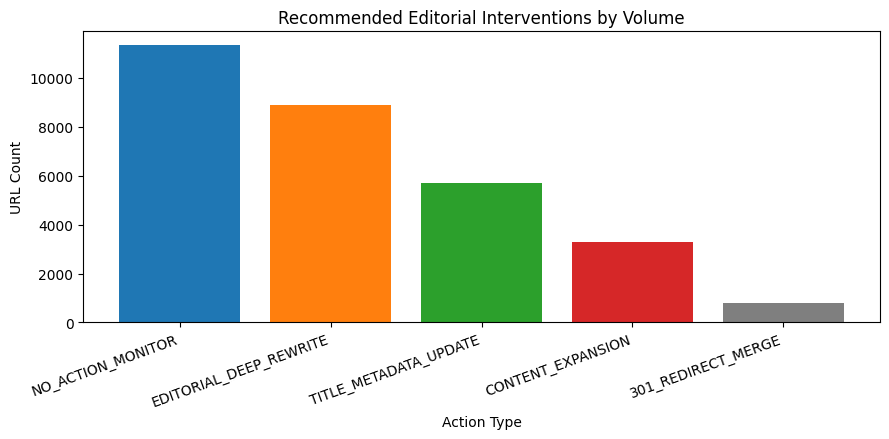

Saved figure: work/figures/playbook_action_distribution.png


In [5]:
import matplotlib.pyplot as plt

# Ensure output directories exist
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# 1. Export Clean Ranked Action Playbook Queue
export_cols = [c for c in ['client_id', 'url', 'recommended_action', 'reason_code', 'intervention_priority', 'opportunity_score', 'impressions', 'avg_position', 'ctr', 'content_age_days'] if c in safe_queue.columns]
final_queue = safe_queue.sort_values(by="opportunity_score", ascending=False)[export_cols].reset_index(drop=True)

final_queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)
print(f"Exported action playbook queue: work/outputs/action_playbook_queue.csv ({len(final_queue)} rows)")

# 2. Export Metrics JSON Receipt
playbook_metrics = {
    "total_recommendations": len(final_queue),
    "high_priority_count": int((final_queue["intervention_priority"] == "High").sum()),
    "action_breakdown": final_queue["recommended_action"].value_counts().to_dict(),
    "reason_code_breakdown": final_queue["reason_code"].value_counts().to_dict(),
    "median_opportunity_score": float(final_queue["opportunity_score"].median())
}

with open("work/outputs/playbook_metrics.json", "w") as f:
    json.dump(playbook_metrics, f, indent=2)
print("Saved receipt: work/outputs/playbook_metrics.json")

# 3. Export Reusable Figures for Paper
plt.figure(figsize=(9, 4.5))
action_counts = final_queue["recommended_action"].value_counts()
plt.bar(action_counts.index, action_counts.values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#7f7f7f'])
plt.title("Recommended Editorial Interventions by Volume")
plt.xlabel("Action Type")
plt.ylabel("URL Count")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig("work/figures/playbook_action_distribution.png", dpi=200)
plt.savefig("work/outputs/playbook_action_distribution.png", dpi=200)
plt.show()
print("Saved figure: work/figures/playbook_action_distribution.png")


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.